## Load required libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 


## Load data from csv file

In [9]:
df = pd.read_csv("house-prices.csv")
df.head(10)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33
5,70,2,True,True,False,North Program Organization,2.050000e+09,68333.33
6,87,2,True,True,True,Pardis,6.000000e+08,20000.00
7,59,1,True,True,True,Shahran,2.150000e+09,71666.67
8,54,2,True,True,False,Andisheh,4.930000e+08,16433.33
9,71,1,True,True,True,West Ferdows Boulevard,2.370000e+09,79000.00


## Data cleaning

In [10]:
cdf = df[["Area", "Room", "Parking","Warehouse","Elevator" ,"Price(USD)", "Address"]]

# converting str value to int
cdf["Area"] = cdf["Area"].str.strip().str.replace(",", "").astype(int)

cdf = cdf[cdf["Area"] < 1200]
cdf = cdf[cdf["Address"].notnull()]


## Data visualization

Text(0, 0.5, 'Price (USD)')

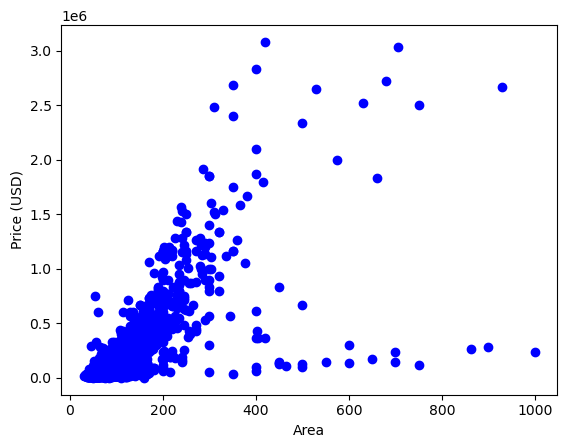

In [11]:
plt.scatter(cdf["Area"], cdf["Price(USD)"], color="b")
plt.xlabel("Area")
plt.ylabel("Price (USD)")

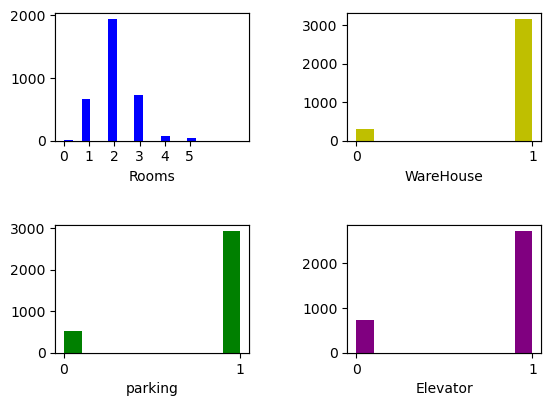

In [12]:
fig, axes = plt.subplots(2,2)
fig.tight_layout(pad=4)

for ax in fig.get_axes():
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
room = plt.subplot2grid((2,2),(0,0))
parking = plt.subplot2grid((2,2),(1,0))
wareHouse = plt.subplot2grid((2,2),(0,1))
elevator = plt.subplot2grid((2,2),(1,1))

room.hist(cdf["Room"], bins=20, color='b', range=(0,7))
room.set_xlabel("Rooms")
room.set_xticks([0,1,2,3,4,5])

parking.hist(cdf["Parking"].astype("int"), bins=10 ,color='g')
parking.set_xlabel("parking")
parking.set_xticks([0,1])

wareHouse.hist(cdf["Warehouse"].astype("int"), bins=10 , color='y')
wareHouse.set_xlabel("WareHouse")
wareHouse.set_xticks([0,1])

elevator.hist(cdf["Elevator"].astype("int"), bins=10 , color='purple')
elevator.set_xlabel("Elevator")
elevator.set_xticks([0,1])

# Random Forest model
## ( This model makes several decision trees and calculates the average between results )

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

X = cdf[["Area", "Room", "Parking", "Warehouse", "Elevator", "Address"]]
Y = cdf[["Price(USD)"]]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=4)

rf_X_train = X_train[["Area", "Room", "Parking", "Warehouse", "Elevator", "Address"]]
rf_Y_train = Y_train[["Price(USD)"]]
rf_X_test = X_test[["Area", "Room", "Parking", "Warehouse", "Elevator", "Address"]]
rf_Y_test = Y_test[["Price(USD)"]]

train_data_rf = X_train.copy()
train_data_rf["Price(USD)"] = rf_Y_train
mapper = train_data_rf.groupby("Address")["Price(USD)"].mean()

rf_X_train["Address"] = rf_X_train["Address"].map(mapper)
rf_X_test["Address"] = rf_X_test["Address"].map(mapper)

overall_mean_price = rf_X_train["Address"].mean()
rf_X_test["Address"] = rf_X_test["Address"].fillna(overall_mean_price)

rf_model = RandomForestRegressor(criterion="squared_error", random_state=4)
rf_model.fit(rf_X_train, rf_Y_train.values.ravel())
y_hat_rf = rf_model.predict(rf_X_test)

print(f"Random Forest r2 score : {r2_score(Y_test, y_hat_rf):.2f}")

Random Forest r2 score : 0.79


<h1> Linear Regression model</h1>
<ul>
<li style="font-size:18px; margin-bottom: 20px;">Regular model</li>
<li style="font-size:18px; margin-bottom: 20px;">Ridge model</li>
<li style="font-size:18px; margin-bottom: 20px;">Lasso model<l/i>

</ul>

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

lr_X_train = X_train[["Area", "Room", "Parking", "Warehouse", "Elevator", "Address"]]
lr_Y_train = Y_train[["Price(USD)"]]
lr_X_test = X_test[["Area", "Room", "Parking", "Warehouse", "Elevator", "Address"]]
lr_Y_test = Y_test[["Price(USD)"]]

train_data_lr = lr_X_train.copy()
train_data_lr["Price(USD)"] = lr_Y_train

mapper = train_data_lr.groupby("Address")["Price(USD)"].mean()

lr_X_train["Address"] = lr_X_train["Address"].map(mapper)
lr_X_test["Address"] = lr_X_test["Address"].map(mapper)

overall_mean_price = lr_X_train["Address"].mean()
lr_X_test["Address"] = lr_X_test["Address"].fillna(overall_mean_price)

regular_model = LinearRegression().fit(lr_X_train, lr_Y_train)
y_hat_regular = regular_model.predict(lr_X_test)

ridge_model = Ridge(alpha=1).fit(lr_X_train, lr_Y_train)
y_hat_ridge = ridge_model.predict(lr_X_test)

lasso_model = Lasso(alpha=1).fit(lr_X_train, lr_Y_train)
y_hat_lasso = lasso_model.predict(lr_X_test)

print(f"reglar linear r2-score :{r2_score(Y_test, y_hat_regular):.2f} ")
print(f"ridge linear r2-score :{r2_score(Y_test, y_hat_ridge):.2f} ")
print(f"lasso linear r2-score :{r2_score(Y_test, y_hat_lasso):.2f} ")

np.set_printoptions(precision=2, suppress=True)

print(f"regular model : \n coefficients : {regular_model.coef_[0]} \n intercept : {regular_model.intercept_} \n")
print(f"ridge model : \n  coefficients : {ridge_model.coef_}  \n intercept : {ridge_model.intercept_} \n")
print(f"lasso model : \n coefficients :{lasso_model.coef_} \n intercept : {lasso_model.intercept_} \n")

reglar linear r2-score :0.62 
ridge linear r2-score :0.62 
lasso linear r2-score :0.62 
regular model : 
 coefficients : [  1640.74  20580.29 -19141.01    878.83   3736.49      0.68] 
 intercept : [-149443.94] 

ridge model : 
  coefficients : [  1640.86  20550.91 -19049.9     840.75   3707.88      0.68]  
 intercept : [-149417.51] 

lasso model : 
 coefficients :[  1640.74  20576.89 -19120.45    858.11   3726.4       0.68] 
 intercept : [-149428.9] 

